In [7]:
import app
import os
import matplotlib.pyplot as plt
import rasterio.plot as rplt
import rasterio
import numpy as np

app.setup_logger(use_console_handler=True, use_file_handler=True)

In [10]:
path = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\L8S2-tucket\2016"
base = r"tile-183_S2_2017-03-01_2017-03-11_10m"

files = [f for f in os.listdir(path) if f.endswith(".tif") and base in f]
files.sort()
splitted_names = files[:-1]
merged_name = files[-1]

In [11]:
splitted = []
for f in splitted_names:
    with rasterio.open(os.path.join(path, f)) as src:
        data = src.read()
        meta = src.meta
        transform = src.transform
        splitted.append((data, meta, transform))

In [12]:
with rasterio.open(os.path.join(path, merged_name)) as src:
    merged_data = src.read()
    merged_meta = src.meta
    merged_transform = src.transform
    merged = (merged_data, merged_meta, merged_transform)

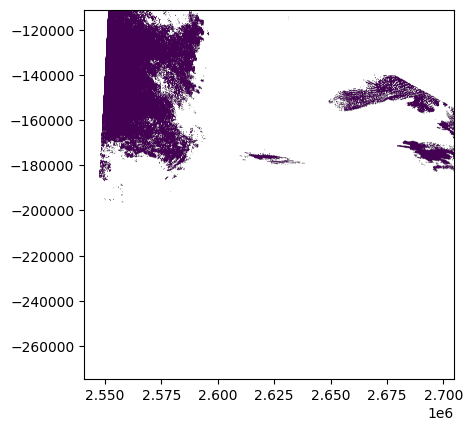

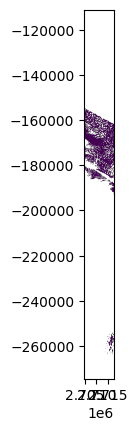

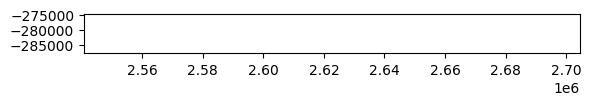

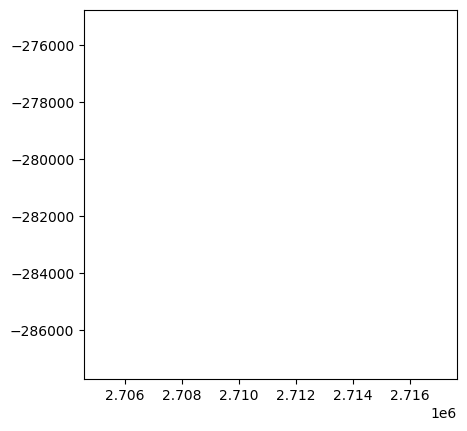

In [20]:
band_id = 0


for i, (data, meta, transform) in enumerate(splitted):
    fig, ax = plt.subplots()
    rplt.show(data[band_id], ax=ax, transform=transform)
    plt.show()


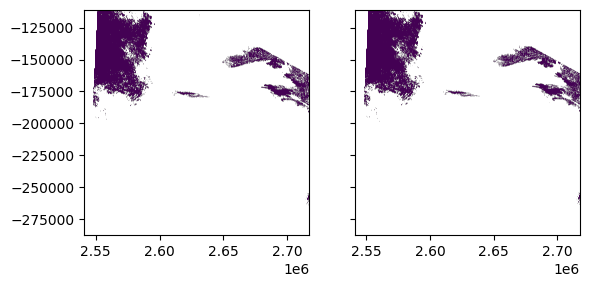

In [21]:
band_id = 0
fig, axes = plt.subplots(1, 2, sharex = True, sharey = True)

ax = axes.ravel()[0]
for i, (data, meta, transform) in enumerate(splitted):
    rplt.show(data[band_id], ax=ax, transform=transform)

ax = axes.ravel()[1]
rplt.show(merged[0][band_id], ax=ax, transform=merged[2])

plt.show()